# 05 - Business recommendations
Every recommendation is generated by `src/08_recommendations.py` from the numbers of the earlier steps - nothing is typed by hand. This notebook turns them into an action plan.

In [1]:
# --- setup: make the project's src/ folder importable and set paths ---
import sys, json
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown
import config as cfg
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
N = json.loads((cfg.TABLES / "key_numbers.json").read_text())   # every number the scripts computed
%matplotlib inline

In [2]:
recs = pd.read_csv(cfg.TABLES / "recommendations.csv")
for _, r in recs.iterrows():
    val = f" - value at stake ${r.value_at_stake_usd/1e6:,.2f}M ({r.value_basis})" if pd.notna(r.value_at_stake_usd) else ""
    display(Markdown(f"**{r.priority}. {r.area}**{val}\n\n*Finding:* {r.finding}\n\n*Action:* {r.action}\n\n*Track:* {r.kpi_to_track}"))

**1. Fix the top lost-revenue SKUs first** - value at stake $7.97M (lost revenue, whole period)

*Finding:* The top 15 SKUs account for 74% of all lost revenue (15 of them are A items); the worst is SKU-00049 with $1.49M.

*Action:* Run a weekly stockout review on these 15 SKUs: confirm lead time, check open POs, raise reorder points before touching the long tail.

*Track:* Lost revenue of top-15 SKUs

**2. Reorder policy refresh** - value at stake $2.30M (lost revenue, last 13 weeks)

*Finding:* Fill rate fell from 92.9% (first 3 months) to 78.7% (last 3 months) while demand grew 12.0% year on year. 164 of 180 SKU-warehouses (91%) have a reorder point below what current demand and actual lead times require; they run a 19.7% stockout-day rate vs 2.1% for the rest.

*Action:* Re-calculate safety stock and reorder point every quarter from the last 13 weeks of demand and the supplier's ACTUAL lead time and its variability. Phase 1: the 20 SKU-warehouses that lost the most revenue in the last 13 weeks ($1.61M, 70% of the total) need about $411K of extra safety stock (59% of today's average inventory value).

*Track:* Fill rate, stockout-day rate, inventory turnover

**3. ABC-differentiated service levels** - value at stake $8.81M (A-class lost revenue, whole period)

*Finding:* A items are 28% of SKUs but 81% of revenue and 82% of lost revenue, yet their fill rate (85.7%) is within 0.8 percentage points of C items (85.0%): every SKU gets the same service-level target.

*Action:* Set service targets by class (for example 98% for A, 95% for B, 90% for C). C items hold only 4.9% of inventory value, so the extra A-item stock has to be budgeted, not funded by trimming C.

*Track:* Fill rate by ABC class, lost revenue in class A

**4. Supplier lead-time reliability**

*Finding:* Only 53.1% of delivered POs arrive on or before the promised date; late POs are 5.0 days late on average. On-time rate ranges from 39.6% (SUP-012) to 68.1% (SUP-015); 5 of 24 suppliers are below 50% on-time.

*Action:* Start a monthly supplier scorecard (on-time %, delay days, lead-time CV), escalate the bottom suppliers, and use measured lead time + variability (not the quoted lead time) in safety-stock formulas.

*Track:* On-time delivery %, lead-time CV by supplier

**5. Expediting cost** - value at stake $0.72M (extra freight vs non-air rates, whole period)

*Finding:* 31% of POs ship by air at 12.0% of goods value vs 4.5% for other modes - about $721K of extra freight over the period.

*Action:* Fewer emergency orders: earlier reorder triggers (see policy refresh) are cheaper than air freight. Review air shipments by SKU and keep air only for A items.

*Track:* Air-freight share of POs, freight % of PO value

**6. Promotion planning**

*Finding:* Promo weeks run at 1.23x the previous 8-week average (normal weeks 0.98x). Stockout rate on promo days is 15.4% vs 12.9% on normal days.

*Action:* Share the promotion calendar with planning and add the promo flag to the forecast (it is the planned, known input the baselines ignore). Build stock one lead time BEFORE a promo.

*Track:* Stockout rate on promo days

**7. Seasonal stock planning**

*Finding:* Electronics swings 0.65 index points between its peak (Aug, 1.30) and low (Feb, 0.66) month; category peaks fall in different months.

*Action:* Adjust reorder points by the monthly seasonal index, so stock is built ahead of each category's peak rather than a flat yearly parameter.

*Track:* Fill rate in peak months by category

**8. Forecasting model choice**

*Finding:* On the untouched test weeks the best baseline (Exp. smoothing) has WAPE 11.4%, linear regression 10.2% and the MLP 10.1%. The MLP beats the best baseline, but adds only 1.3% relative improvement over linear regression. Chosen model: Linear regression.

*Action:* Use Linear regression for weekly forecasts (promo flag + recent demand + month), keep the Exp. smoothing as the fallback and the MLP as a challenger to re-test each quarter.

*Track:* WAPE, bias on a rolling basis

**9. Forecast accuracy -> safety stock**

*Finding:* Using the MLP's forecast errors instead of the Exp. smoothing's changes the indicative safety-stock requirement by -14.8% ($176K -> $150K).

*Action:* Size safety stock from forecast error (not raw demand variability) once the forecast is live; track the realised error each month.

*Track:* Forecast error std per SKU, safety-stock value

**10. Data quality at the source**

*Finding:* Cleaning corrected or removed 5,998 records (duplicates, impossible values, mixed formats).

*Action:* Add input validation in the ERP export: unique keys, non-negative quantities, ISO dates, controlled category lists.

*Track:* Rows rejected by validation per load

## Where the money is
Value at stake per recommendation (different time bases, see the label - compare with care).

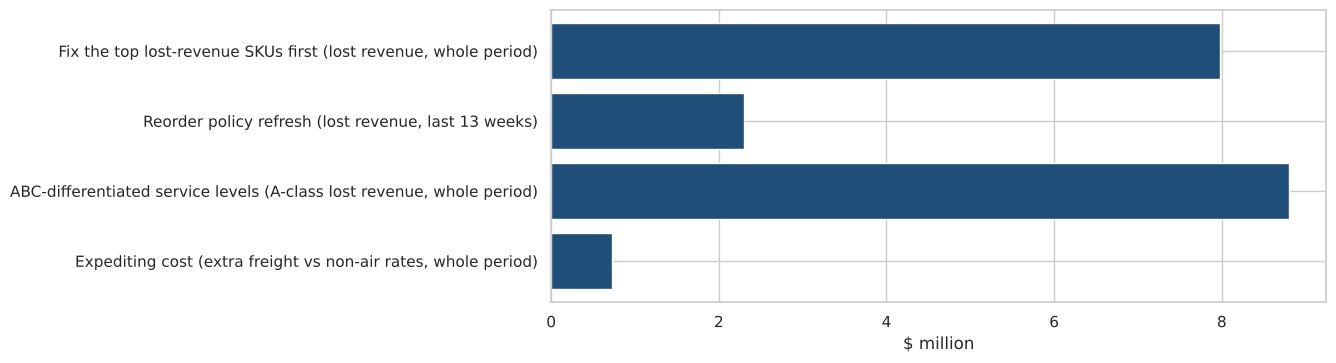

In [3]:
v = recs.dropna(subset=["value_at_stake_usd"]).copy(); v["label"] = v["area"] + " (" + v["value_basis"] + ")"
fig, ax = plt.subplots(figsize=(10, 3.8)); ax.barh(v["label"], v["value_at_stake_usd"] / 1e6, color="#1f4e79"); ax.invert_yaxis(); ax.set_xlabel("$ million"); plt.show()

## 30-60-90 day plan (structure; owners to be assigned by the business)

In [4]:
plan = pd.DataFrame({
    "when": ["Week 1-2", "Week 2-4", "Month 2", "Month 3"],
    "action": ["Weekly stockout review of the top-15 lost-revenue SKUs", "Phase-1 reorder-point/safety-stock refresh for the worst SKU-warehouses",
               "Service targets by ABC class + supplier scorecard + promo calendar shared with planning", "Quarterly policy refresh process; weekly forecast with promo flag; re-test the neural-network challenger"],
    "kpi": ["lost revenue of top-15 SKUs", "stockout-day rate of phase-1 group", "fill rate by ABC class, on-time %", "WAPE, bias, overall fill rate"]})
display(plan)

,when,action,kpi
0,Week 1-2,Weekly stockout review of the top-15 lost-reve...,lost revenue of top-15 SKUs
1,Week 2-4,Phase-1 reorder-point/safety-stock refresh for...,stockout-day rate of phase-1 group
2,Month 2,Service targets by ABC class + supplier scorec...,"fill rate by ABC class, on-time %"
3,Month 3,Quarterly policy refresh process; weekly forec...,"WAPE, bias, overall fill rate"


In [5]:
display(Markdown(f"""### Summary
Fill rate **{N['kpi_fill_rate']:.1%}**, lost revenue **${N['kpi_lost_revenue']/1e6:,.2f}M**. The biggest levers: the top-15 SKUs ({N['kpi_top15_lost_share']:.0%} of the loss), refreshing the reorder policy ({N['pol_under_share']:.0%} of SKU-warehouses under-protected) and differentiating service by ABC class. The forecast model is {N['fc_final_model']}; the neural network stays a challenger."""))

### Summary
Fill rate **85.6%**, lost revenue **$10.76M**. The biggest levers: the top-15 SKUs (74% of the loss), refreshing the reorder policy (91% of SKU-warehouses under-protected) and differentiating service by ABC class. The forecast model is Linear regression; the neural network stays a challenger.